# <font color=' palegreen'>Data Science CA 5 & 6</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

##<font color='orange'>**Task 4 - Image Segmentation Using Clustering Methods**</font>


### <font color='skyblue'>1. Loading the dataset</font>

We load the dataset and apply the resize factor. Here we also sample 50 images and show some of them.

In [1]:
import os

if not os.path.exists("dataset_flag"):
  !gdown 1VbGVsAR4grEpsmNtIqTZc8iiDelUHOlQ
  !unzip -q FootballPlayerSegmentationDataset.zip -d football_dataset
  !touch dataset_flag

Downloading...
From (original): https://drive.google.com/uc?id=1VbGVsAR4grEpsmNtIqTZc8iiDelUHOlQ
From (redirected): https://drive.google.com/uc?id=1VbGVsAR4grEpsmNtIqTZc8iiDelUHOlQ&confirm=t&uuid=246e2a6d-fc6d-4351-8d5f-baea556791de
To: /content/FootballPlayerSegmentationDataset.zip
100% 333M/333M [00:02<00:00, 133MB/s]


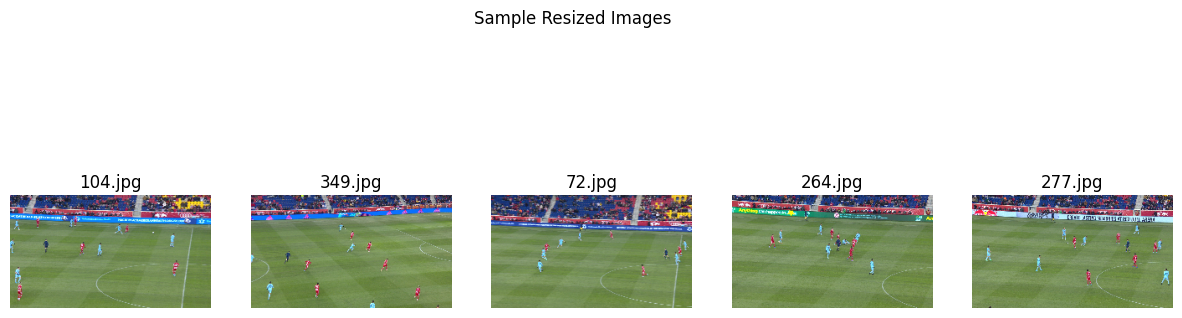

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# Path to image folder
image_folder = 'football_dataset/images'
image_filenames = os.listdir(image_folder)

# Randomly sample 50 images
random.seed(32)
sampled_files = random.sample(image_filenames, 50)

# Resize factor (1/8)
resize_factor = 1/8

# Load and resize images
resized_images = []
for filename in sampled_files:
    img_path = os.path.join(image_folder, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    h, w = img.shape[:2]
    img_resized = cv2.resize(img, (int(w * resize_factor), int(h * resize_factor)))
    resized_images.append((filename, img_resized))

# Visualize a few resized images
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(resized_images[i][1])
    plt.axis('off')
    plt.title(resized_images[i][0])
plt.suptitle('Sample Resized Images')
plt.show()


### <font color='skyblue'>2. Creating Features </font>

In this section we try different combinations of following features to extract best feature set for the task:

1. RGB & HSV (related to image colors)
3. X & Y (spatial)
2. Edges

In [3]:
def extract_features_advanced(img, method='rgb+xy'):
    h, w, _ = img.shape
    rgb = img.reshape(-1, 3)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).reshape(-1, 3)
    x_coords = np.tile(np.arange(w), (h, 1)).reshape(-1, 1)
    y_coords = np.tile(np.arange(h).reshape(-1, 1), (1, w)).reshape(-1, 1)
    coords = np.hstack((x_coords, y_coords))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx ** 2 + sobely ** 2)
    edges = magnitude.reshape(-1, 1)

    if method == 'rgb':
        return rgb

    elif method == 'hsv':
        return hsv

    elif method == 'rgb+xy':
        return np.hstack((rgb, coords))

    elif method == 'hsv+xy':
        return np.hstack((hsv, coords))

    elif method == 'rgb+edges':
        return np.hstack((rgb, edges))

    elif method == 'rgb+xy+edges':
        return np.hstack((rgb, coords, edges))

    elif method == 'hsv+xy+edges':
        return np.hstack((hsv, coords, edges))

    elif method == 'rgb+hsv+xy+edges':
        return np.hstack((rgb, hsv, coords, edges))

    elif method == '2rgb+2hsv+xy+edges':
        return np.hstack((rgb, rgb, rgb, rgb, hsv, hsv, coords, coords))

    elif method == 'xy+edges':
        return np.hstack((coords, edges))

    else:
        raise ValueError(f"Unknown method: {method}")


### <font color='skyblue'>3. Cluster Pixels </font>

In this part we use K-Means and DBSCAN as our clustering algorithms, the hyperparameters ar chosen by trial & error on different reasonable values, based on how they seem to classify players better on sample.

We also tried Agglomerative clustering but omit it since it was very time consuming.

In [4]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

def cluster_and_visualize(img, method='rgb+xy',
                          algo='kmeans',
                          n_clusters=6,
                          eps=5, min_samples=5):
    """
    Cluster image pixels using selected algorithm and visualize results.

    Args:
        img: input image (H,W,3)
        method: feature extraction method from extract_features_advanced
        algo: 'kmeans' or 'dbscan'
        n_clusters: number of clusters (for kmeans)
        eps, min_samples: DBSCAN parameters
    """
    features = extract_features_advanced(img, method)
    h, w, _ = img.shape

    # --- KMeans ---
    if algo == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
        labels = model.fit_predict(features)
        clustered = labels.reshape(h, w)
        inertia = model.inertia_
        silhouette = silhouette_score(features, labels)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(clustered, cmap='nipy_spectral')
        plt.title(f"KMeans ({method})\nK={n_clusters}, Sil={silhouette:.2f}, Inertia={inertia:.1f}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # --- DBSCAN ---
    elif algo == 'dbscan':
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(features)
        clustered = labels.reshape(h, w)

        # compute silhouette only if >1 cluster (ignoring noise -1)
        if len(np.unique(labels)) > 1 and np.any(labels != -1):
            silhouette = silhouette_score(features, labels)
        else:
            silhouette = -1

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(clustered, cmap='nipy_spectral')
        plt.title(f"DBSCAN ({method})\neps={eps}, min_samples={min_samples}, Sil={silhouette:.2f}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("algo must be 'kmeans' or 'dbscan'")

    return clustered


In [5]:
# methods = [
#     'rgb', 'hsv', 'rgb+xy', 'hsv+xy',
#     'rgb+edges', 'rgb+xy+edges', 'xy+edges',
#     'hsv+xy+edges', 'rgb+hsv+xy+edges', '2rgb+2hsv+xy+edges'
# ]
methods = [
    'rgb', 'rgb+xy', 'rgb+xy+edges', 'xy+edges'
]

sample_img = resized_images[0][1]

clustered_results = {}

# Define configs you want to test
configs = [
    {"algo": "kmeans", "n_clusters": 6},              # KMeans baseline
    # {"algo": "kmeans", "n_clusters": 8},              # Another KMeans
    {"algo": "dbscan", "eps": 5, "min_samples": 10},  # DBSCAN variant
    {"algo": "dbscan", "eps": 10, "min_samples": 10},  # DBSCAN variant
]

for method in methods:
    for cfg in configs:
        print(f"\n=== Clustering using method: {method}, config: {cfg} ===")
        clustered = cluster_and_visualize(
            sample_img,
            method=method,
            algo=cfg.get("algo", "kmeans"),
            n_clusters=cfg.get("n_clusters", 6),
            eps=cfg.get("eps", 5),
            min_samples=cfg.get("min_samples", 5)
        )
        clustered_results[(method, str(cfg))] = clustered


Output hidden; open in https://colab.research.google.com to view.

### <font color='skyblue'>4. Filtering and Merging </font>

The function filter_and_merge_proximity is an enhanced post-processing step applied after clustering. It first removes noisy segments by filtering out connected components that are too small (area < min_area) or too large (area > max_area_ratio × image size). For each valid component, it computes its centroid. In a second stage, it merges components whose centroids lie within a specified pixel distance (merge_distance), effectively combining fragmented regions that belong to the same object. Finally, the function re-labels all remaining regions consecutively so that each object has a unique, clean label. This approach reduces over-segmentation, removes spurious noise, and yields more coherent segments for evaluation and visualization.

In [6]:
from scipy import ndimage
from scipy.spatial.distance import cdist
import numpy as np

def filter_and_merge_proximity(clustered_img, min_area=6, max_area_ratio=0.01, merge_distance=5):
    """
    Filters small/large components and merges clusters that are close to each other.

    Args:
        clustered_img: 2D array of cluster labels (H x W)
        min_area: minimum component area to keep
        max_area_ratio: maximum component area as fraction of total image
        merge_distance: distance in pixels to merge nearby components

    Returns:
        merged_img: filtered and merged image
    """
    h, w = clustered_img.shape
    total_area = h * w
    max_area = total_area * max_area_ratio

    # Step 1: Filter small/large components
    filtered = np.zeros_like(clustered_img, dtype=np.int32)
    new_label = 1
    component_centroids = {}  # Store centroids for merging

    for label in np.unique(clustered_img):
        if label == 0:
            continue
        mask = (clustered_img == label).astype(np.uint8)
        labeled_mask, num_features = ndimage.label(mask)

        for i in range(1, num_features + 1):
            component = (labeled_mask == i)
            size = component.sum()
            if min_area <= size <= max_area:
                filtered[component] = new_label
                # store centroid
                coords = np.column_stack(np.nonzero(component))
                centroid = coords.mean(axis=0)
                component_centroids[new_label] = centroid
                new_label += 1

    # Step 2: Merge components that are close together
    labels = list(component_centroids.keys())
    centroids = np.array([component_centroids[l] for l in labels])

    merged_map = filtered.copy()
    merged_labels = {l: l for l in labels}  # keep track of merges

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            dist = np.linalg.norm(centroids[i] - centroids[j])
            if dist <= merge_distance:
                # Merge j into i
                merged_map[filtered == labels[j]] = labels[i]
                merged_labels[labels[j]] = labels[i]

    # Optional: re-label consecutively
    unique_labels = np.unique(merged_map)
    relabeled = np.zeros_like(merged_map)
    for new_label, old_label in enumerate(unique_labels[unique_labels > 0], start=1):
        relabeled[merged_map == old_label] = new_label

    return relabeled


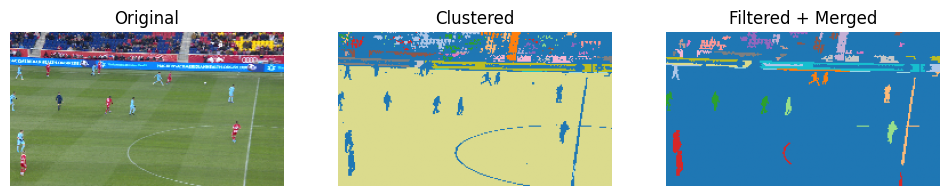

In [7]:
from scipy import ndimage
clustered = clustered_results[("rgb+xy","{'algo': 'dbscan', 'eps': 10, 'min_samples': 10}")]
# Apply filter & merge
filtered = filter_and_merge_proximity(clustered, min_area=10, max_area_ratio=0.07)

# Show before vs after
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(resized_images[0][1]); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(clustered, cmap="tab20"); plt.title("Clustered"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(filtered, cmap="tab20"); plt.title("Filtered + Merged"); plt.axis("off")
plt.show()


### <font color='skyblue'>5.  Even More Clustering! </font>

We generate binay masks as told but since usually the top side of pictures is related to crowd and it's clusters are mistaken with players due to difference of color with field and having clusters almost same size as players, we omit it from mask and don't report top 25% of picture as player.

In [9]:
def generate_binary_mask(clustered_img, crop_ratio=0.25):
    """
    Convert clustered image into binary mask (players=1, background=0),
    while ignoring the top crop_ratio of the image.
    """
    h, w = clustered_img.shape
    binary_mask = (clustered_img > 0).astype(np.uint8)

    # Zero out the top part (ignored region)
    crop_h = int(h * crop_ratio)
    binary_mask[:crop_h, :] = 0

    return binary_mask


def get_centroids(binary_mask, crop_ratio=0.25):
    """
    Find connected components and their centroids, ignoring the
    top crop_ratio of the image.
    """
    h, w = binary_mask.shape
    # Make a copy to avoid changing original mask
    mask_copy = binary_mask.copy()

    # Ignore top part
    crop_h = int(h * crop_ratio)
    mask_copy[:crop_h, :] = 0

    # Connected components and centroids
    labeled_mask, num_labels = ndimage.label(mask_copy)
    centroids = ndimage.center_of_mass(mask_copy, labeled_mask, range(1, num_labels + 1))

    return labeled_mask, centroids


In [10]:
def process_filtered_binary_mask(filtered):
    binary = generate_binary_mask(filtered)

    plt.figure(figsize=(6, 4))
    plt.imshow(filtered, cmap="nipy_spectral")
    plt.imshow(binary)
    plt.title(f'Binary Mask')
    plt.axis('off')
    plt.show()

    return binary


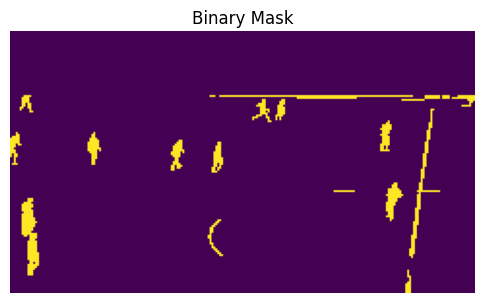

In [11]:
binary = process_filtered_binary_mask(filtered)

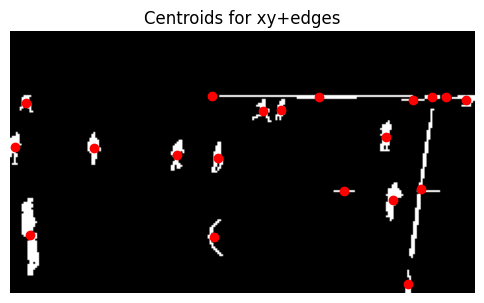

In [12]:
labeled_mask, centroids = get_centroids(binary)

plt.figure(figsize=(6, 6))
plt.imshow(binary, cmap='gray')
for y, x in centroids:
    plt.plot(x, y, 'ro')
plt.title(f"Centroids for {method}")
plt.axis('off')
plt.show()


### <font color='skyblue'>7.  Evaluation </font>

In this part, we evaluate the quality of our unsupervised segmentation results against the ground-truth player annotations provided in COCO format. After clustering the pixels using the DBSCAN algorithm with rgb+xy features (eps=10, min_samples=10) and post-processing with filtering and merging, we generate binary masks representing predicted player regions. These masks are then compared to the ground-truth masks using two standard metrics: the Dice coefficient, which measures overall overlap, and the Intersection over Union (IoU), which is a stricter measure of overlap quality. Running the evaluation across 50 sampled images, we obtained an average Dice score of 0.598 and an average IoU of 0.440, which indicates a reasonably strong agreement between the unsupervised clustering output and the annotated ground truth. This demonstrates that DBSCAN, combined with spatial features and filtering, can effectively capture player regions without requiring supervised training.

In [38]:
from pycocotools.coco import COCO

# Load COCO annotations
coco = COCO("football_dataset/annotations/instances_default.json")

# --- Metrics ---
def dice_coefficient(pred, gt):
    intersection = np.sum(pred * gt)
    return (2. * intersection) / (np.sum(pred) + np.sum(gt) + 1e-8)

def iou_score(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt) - intersection
    return intersection / (union + 1e-8)

# --- Load Ground Truth ---
def load_ground_truth_coco(coco, image_id, target_shape):
    anns = coco.loadAnns(coco.getAnnIds(imgIds=image_id))
    img_info = coco.loadImgs(image_id)[0]
    orig_h, orig_w = img_info["height"], img_info["width"]
    mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

    for ann in anns:
        if ann["category_id"] == 1:  # assuming 'player' has id=1
            m = coco.annToMask(ann)
            mask = np.maximum(mask, m)

    mask_resized = cv2.resize(mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask_resized

# --- Full Evaluation ---
def evaluate_masks(resized_images, predicted_masks, coco):
    dice_scores, iou_scores = [], []

    for (filename, img), pred_mask in zip(resized_images, predicted_masks):
        img_id = next((iid for iid in coco.getImgIds()
                       if coco.loadImgs(iid)[0]["file_name"] == filename), None)
        if img_id is None:
            continue

        gt_mask = load_ground_truth_coco(coco, img_id, img.shape)

        pred_mask_resized = cv2.resize(pred_mask.astype(np.uint8),
                                       (img.shape[1], img.shape[0]),
                                       interpolation=cv2.INTER_NEAREST)

        dice_scores.append(dice_coefficient(pred_mask_resized, gt_mask))
        iou_scores.append(iou_score(pred_mask_resized, gt_mask))

    return dice_scores, iou_scores


# --- Step 1: Run clustering with chosen config ---
predicted_masks = []
for filename, img in resized_images:
    clustered = cluster_and_visualize(img,
                                      method="rgb+xy",
                                      algo="dbscan",
                                      eps=10,
                                      min_samples=10)
    # Postprocess: filter + binary mask
    filtered = filter_and_merge_proximity(clustered)
    binary = generate_binary_mask(filtered)
    predicted_masks.append(binary)


# --- Step 2: Evaluate over dataset ---
dice_scores, iou_scores = evaluate_masks(resized_images, predicted_masks, coco)

print(f"Average Dice over 50 images: {np.mean(dice_scores):.3f}")
print(f"Average IoU  over 50 images: {np.mean(iou_scores):.3f}")


Output hidden; open in https://colab.research.google.com to view.

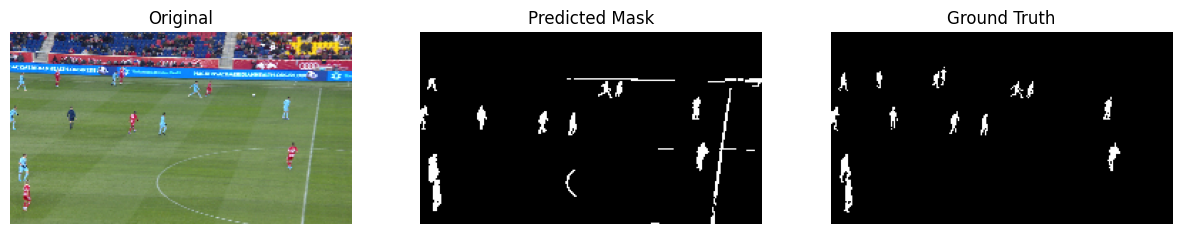

In [39]:
# Pick one image
filename, img = resized_images[0]
pred_mask = predicted_masks[0]
img_id = next((iid for iid in coco.getImgIds()
               if coco.loadImgs(iid)[0]["file_name"] == filename), None)
gt_mask = load_ground_truth_coco(coco, img_id, img.shape)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(pred_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(gt_mask, cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
plt.show()


##<font color='orange'>**Questions**</font>

* **Provide an example of a segmentation task where each type of
segmentation—semantic, instance, and panoptic—is appropriate and sufficient, and explain why each type suits the specific task.**

1. Semantic Segmentation: Suitable when we only care about what each pixel represents, not which instance it belongs to.

Example: Segmenting a satellite image into “land,” “water,” and “urban area.”
Here, distinguishing between individual objects is not important—only the overall class of each region matters.

2. Instance Segmentation: Needed when we must separate individual objects of the same class.

Example: Detecting and segmenting cars in a traffic camera feed. Every car must be uniquely identified because counting and tracking each vehicle is required, not just labeling all pixels as “car.”

3. Panoptic Segmentation: Useful when we want a complete understanding of the scene that combines both semantic and instance segmentation.

Example: In autonomous driving, we need to label “road,” “sky,” and “buildings” (semantic) while also identifying each pedestrian and vehicle separately (instance). Panoptic segmentation merges these requirements into one coherent task.

---------

* **Explain the difference between the Dice coefficient and Intersection over Union (IoU) as evaluation metrics in image segmentation. In what scenarios might one be
preferred over the other?**

1. Intersection over Union (IoU):
$$IoU=\frac{|Pred \cap GT|}{|Pred \cup GT|}$$


Measures the ratio of overlap to the total combined area. It penalizes both false positives and false negatives.

2. Dice Coefficient:

$$Dice=\frac{2|Pred \cap GT|}{|Pred|+|GT|}$$


Similar to IoU, but gives more weight to the overlap relative to the total size of the two masks.

Key Differences:

Dice is generally more sensitive to small objects, because it emphasizes overlap relative to object size.

IoU is stricter, as it divides by the union, making it harder to achieve a high score.

When to prefer each:

Use Dice when dealing with medical imaging or cases with small, sparse objects (e.g., tumors, lesions).

Use IoU for object detection/segmentation benchmarks, where strict overlap measurement is standard.

----

* **Imagine a scenario where we need to cluster a large set of images into multiple
categories. Methods such as K-means can become computationally expensive and
inefficient when applied directly to high-dimensional image data. One approach to
address this issue is to use an autoencoder architecture to reduce the dimensionality
of the images before clustering. Explain how autoencoders can be used for this
purpose. How does this method help improve the efficiency and effectiveness of
clustering algorithms like K-means on large image datasets?**

The Challenge: Images are high-dimensional (e.g., a 256×256 RGB image = 196,608 dimensions). Running clustering directly on such data is computationally expensive and noisy.

Autoencoder Solution:

An autoencoder is a neural network trained to reconstruct its input by passing data through a bottleneck (low-dimensional latent space).

The encoder compresses the image into a compact feature vector (e.g., 128 or 256 dimensions).

The decoder reconstructs the image from this compressed representation.

For Clustering: After training, we discard the decoder and use the encoder to generate latent representations for all images. Clustering (e.g., with K-means) is then applied in this lower-dimensional space.

Benefits:

Efficiency: Reduces computation since clustering operates on compact feature vectors instead of raw pixels.

Effectiveness: The encoder learns meaningful representations (edges, shapes, textures) that improve clustering quality compared to raw pixel values.

Scalability: Enables clustering on large datasets that would otherwise be infeasible with raw image data.